In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Building_Permits.csv')

/tmp/ipykernel_284/808256141.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/Building_Permits.csv')


In [ ]:
df


,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,NaN,Ellis,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.785719256680785, -122.40852313194863)",1.380611e+12
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,NaN,Geary,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.78733980600732, -122.41063199757738)",1.420164e+12
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,NaN,Pacific,Av,...,1.0,constr type 1,1.0,constr type 1,NaN,3.0,Russian Hill,94109.0,"(37.7946573324287, -122.42232562979227)",1.424857e+12
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,NaN,Pacific,Av,...,5.0,wood frame (5),5.0,wood frame (5),NaN,3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",1.443574e+12
4,201611283529,6,demolitions,11/28/2016,0342,001,950,NaN,Market,St,...,3.0,constr type 3,NaN,NaN,NaN,6.0,Tenderloin,94102.0,"(37.78315261897309, -122.40950883997789)",1.445482e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20895,201308073732,8,otc alterations permit,08/07/2013,0177,004,614,NaN,Jackson,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,3.0,Chinatown,94133.0,"(37.796353026519824, -122.40555154064296)",1.313469e+11
20896,201308073733,8,otc alterations permit,08/07/2013,0300,003,725,NaN,Leavenworth,St,...,3.0,constr type 3,3.0,constr type 3,NaN,3.0,Nob Hill,94109.0,"(37.78777524597649, -122.41537312631039)",1.313469e+12
20897,201308073734,8,otc alterations permit,08/07/2013,0604,028,2275,NaN,Jackson,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,2.0,Pacific Heights,94115.0,"(37.79247391323853, -122.43238652085589)",1.313471e+11
20898,201308073735,8,otc alterations permit,08/07/2013,5977,009,500,NaN,Burrows,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,9.0,Portola,94134.0,"(37.7279719694203, -122.40827763773702)",1.313471e+12


In [ ]:
df.isnull().sum()

,0
Permit Number,0
Permit Type,0
Permit Type Definition,0
Permit Creation Date,0
Block,0
Lot,0
Street Number,0
Street Number Suffix,20675
Street Name,0
Street Suffix,262


In [ ]:
df=df.drop(columns=['Street Number Suffix','Structural Notification','Voluntary Soft-Story Retrofit','TIDF Compliance','Site Permit','Fire Only Permit','Unit','Unit Suffix'],axis=1)

In [ ]:
df['Filed Date'] = pd.to_datetime(df['Filed Date'], errors='coerce')
df['Issued Date'] = pd.to_datetime(df['Issued Date'], errors='coerce')
df['Completed Date'] = pd.to_datetime(df['Completed Date'], errors='coerce')

df['processing_days'] = (df['Issued Date'] - df['Filed Date']).dt.days
df['completion_days'] = (df['Completed Date'] - df['Issued Date']).dt.days

df['year'] = df['Filed Date'].dt.year
df['month'] = df['Filed Date'].dt.month

In [ ]:
df.isnull().sum()

,0
Permit Number,0
Permit Type,0
Permit Type Definition,0
Permit Creation Date,0
Block,0
Lot,0
Street Number,0
Street Name,0
Street Suffix,262
Description,32


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20900 entries, 0 to 20899
Data columns (total 39 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Permit Number                           20900 non-null  object        
 1   Permit Type                             20900 non-null  int64         
 2   Permit Type Definition                  20900 non-null  object        
 3   Permit Creation Date                    20900 non-null  object        
 4   Block                                   20900 non-null  object        
 5   Lot                                     20900 non-null  object        
 6   Street Number                           20900 non-null  int64         
 7   Street Name                             20900 non-null  object        
 8   Street Suffix                           20638 non-null  object        
 9   Description                             20868 non-

In [ ]:
df= df.dropna(subset=['processing_days'])

In [ ]:
df.isnull().sum()

,0
Permit Number,0
Permit Type,0
Permit Type Definition,0
Permit Creation Date,0
Block,0
Lot,0
Street Number,0
Street Name,0
Street Suffix,252
Description,10


In [ ]:
df=df.dropna(subset=['Completed Date'])

In [ ]:
df = df.dropna(subset=['Location'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12289 entries, 3 to 20898
Data columns (total 39 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Permit Number                           12289 non-null  object        
 1   Permit Type                             12289 non-null  int64         
 2   Permit Type Definition                  12289 non-null  object        
 3   Permit Creation Date                    12289 non-null  object        
 4   Block                                   12289 non-null  object        
 5   Lot                                     12289 non-null  object        
 6   Street Number                           12289 non-null  int64         
 7   Street Name                             12289 non-null  object        
 8   Street Suffix                           12146 non-null  object        
 9   Description                             12284 non-null 

In [ ]:
df.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Name,Street Suffix,Description,...,Proposed Construction Type Description,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID,processing_days,completion_days,year,month
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,Pacific,Av,repair dryrot & stucco at front of bldg.,...,wood frame (5),3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",1.443574e+12,253.0,6.0,2016.0,11.0
6,201706300814,8,otc alterations permit,06/30/2017,1739,020,1291,11th,Av,re-roofing,...,wood frame (5),5.0,Inner Sunset,94122.0,"(37.764145640138565, -122.46875112470363)",1.468970e+12,0.0,12.0,2017.0,6.0
48,201710110928,8,otc alterations permit,10/11/2017,5934,020,938,Felton,St,reroofing,...,wood frame (5),9.0,Portola,94134.0,"(37.72775517946509, -122.41419227409298)",1.482932e+12,0.0,20.0,2017.0,10.0
91,201407080724,3,additions alterations or repairs,07/08/2014,5900A,025,801,Silver,Av,new sprinkler system. 94 heads. ref: 2014-11-1...,...,constr type 3,9.0,Portola,94134.0,"(37.7295502279417, -122.41833852987313)",1.348201e+12,430.0,728.0,2014.0,7.0
92,201408254591,8,otc alterations permit,08/25/2014,3509,029,63,Grace,St,to comply with physical inspection report cc7777,...,wood frame (5),6.0,South of Market,94103.0,"(37.774944547030586, -122.41443674356925)",1.353299e+12,0.0,1136.0,2014.0,8.0


In [ ]:
df['Proposed Units']=df['Proposed Units'].fillna(df['Proposed Units'].median())

In [ ]:
df=df.dropna(subset=['Existing Units'])

In [ ]:
df=df.dropna()

In [ ]:
df.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Name,Street Suffix,Description,...,Proposed Construction Type Description,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID,processing_days,completion_days,year,month
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,Pacific,Av,repair dryrot & stucco at front of bldg.,...,wood frame (5),3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",1.443574e+12,253.0,6.0,2016.0,11.0
6,201706300814,8,otc alterations permit,06/30/2017,1739,020,1291,11th,Av,re-roofing,...,wood frame (5),5.0,Inner Sunset,94122.0,"(37.764145640138565, -122.46875112470363)",1.468970e+12,0.0,12.0,2017.0,6.0
48,201710110928,8,otc alterations permit,10/11/2017,5934,020,938,Felton,St,reroofing,...,wood frame (5),9.0,Portola,94134.0,"(37.72775517946509, -122.41419227409298)",1.482932e+12,0.0,20.0,2017.0,10.0
92,201408254591,8,otc alterations permit,08/25/2014,3509,029,63,Grace,St,to comply with physical inspection report cc7777,...,wood frame (5),6.0,South of Market,94103.0,"(37.774944547030586, -122.41443674356925)",1.353299e+12,0.0,1136.0,2014.0,8.0
101,201604064066,8,otc alterations permit,04/06/2016,1497,016E,583,47th,Av,permeation grouting of 22 lineal ft of foundation,...,wood frame (5),1.0,Outer Richmond,94121.0,"(37.77743123832622, -122.50842623186071)",1.418654e+12,0.0,540.0,2016.0,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11001 entries, 3 to 20898
Data columns (total 39 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Permit Number                           11001 non-null  object        
 1   Permit Type                             11001 non-null  int64         
 2   Permit Type Definition                  11001 non-null  object        
 3   Permit Creation Date                    11001 non-null  object        
 4   Block                                   11001 non-null  object        
 5   Lot                                     11001 non-null  object        
 6   Street Number                           11001 non-null  int64         
 7   Street Name                             11001 non-null  object        
 8   Street Suffix                           11001 non-null  object        
 9   Description                             11001 non-null 

In [ ]:
df['Permit Creation Date']=pd.to_datetime(df['Permit Creation Date'])

In [ ]:
df=df.drop(columns=['Block','Lot','Permit Number','Record ID'],axis=1)

In [ ]:
df.head()

,Permit Type,Permit Type Definition,Permit Creation Date,Street Number,Street Name,Street Suffix,Description,Current Status,Current Status Date,Filed Date,...,Proposed Construction Type,Proposed Construction Type Description,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,processing_days,completion_days,year,month
3,8,otc alterations permit,2016-11-07,1230,Pacific,Av,repair dryrot & stucco at front of bldg.,complete,07/24/2017,2016-11-07,...,5.0,wood frame (5),3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",253.0,6.0,2016.0,11.0
6,8,otc alterations permit,2017-06-30,1291,11th,Av,re-roofing,complete,07/12/2017,2017-06-30,...,5.0,wood frame (5),5.0,Inner Sunset,94122.0,"(37.764145640138565, -122.46875112470363)",0.0,12.0,2017.0,6.0
48,8,otc alterations permit,2017-10-11,938,Felton,St,reroofing,complete,10/31/2017,2017-10-11,...,5.0,wood frame (5),9.0,Portola,94134.0,"(37.72775517946509, -122.41419227409298)",0.0,20.0,2017.0,10.0
92,8,otc alterations permit,2014-08-25,63,Grace,St,to comply with physical inspection report cc7777,complete,10/04/2017,2014-08-25,...,5.0,wood frame (5),6.0,South of Market,94103.0,"(37.774944547030586, -122.41443674356925)",0.0,1136.0,2014.0,8.0
101,8,otc alterations permit,2016-04-06,583,47th,Av,permeation grouting of 22 lineal ft of foundation,complete,09/28/2017,2016-04-06,...,5.0,wood frame (5),1.0,Outer Richmond,94121.0,"(37.77743123832622, -122.50842623186071)",0.0,540.0,2016.0,4.0


In [ ]:
df.describe()

,Permit Type,Permit Creation Date,Street Number,Filed Date,Issued Date,Completed Date,Number of Existing Stories,Number of Proposed Stories,Estimated Cost,Revised Cost,...,Proposed Units,Plansets,Existing Construction Type,Proposed Construction Type,Supervisor District,Zipcode,processing_days,completion_days,year,month
count,11001.000000,11001,11001.000000,11001,11001,11001,11001.000000,11001.000000,1.100100e+04,1.100100e+04,...,11001.000000,11001.000000,11001.000000,11001.000000,11001.000000,11001.000000,11001.000000,11001.000000,11001.000000,11001.000000
mean,7.692664,2013-04-26 10:50:09.980910592,1107.907099,2013-04-26 14:15:09.080992768,2013-05-17 02:13:46.615762176,2013-11-05 16:48:41.625306880,5.147896,5.161622,4.498464e+04,5.434174e+04,...,13.747750,1.073357,4.191437,4.191801,5.644669,94115.627125,20.499046,172.607581,2013.012726,4.198982
min,2.000000,2012-03-28 00:00:00,1.000000,2013-01-02 00:00:00,2013-01-02 00:00:00,2013-01-04 00:00:00,0.000000,0.000000,1.000000e+00,1.000000e+00,...,0.000000,0.000000,1.000000,1.000000,1.000000,94102.000000,0.000000,0.000000,2013.000000,1.000000
25%,8.000000,2013-02-27 00:00:00,235.000000,2013-02-27 00:00:00,2013-03-07 00:00:00,2013-05-30 00:00:00,2.000000,2.000000,3.000000e+03,3.000000e+03,...,1.000000,0.000000,5.000000,5.000000,3.000000,94109.000000,0.000000,37.000000,2013.000000,2.000000
50%,8.000000,2013-04-24 00:00:00,674.000000,2013-04-24 00:00:00,2013-05-06 00:00:00,2013-08-22 00:00:00,3.000000,3.000000,1.000000e+04,1.050000e+04,...,1.000000,2.000000,5.000000,5.000000,6.000000,94114.000000,0.000000,98.000000,2013.000000,4.000000
75%,8.000000,2013-06-14 00:00:00,1670.000000,2013-06-14 00:00:00,2013-06-27 00:00:00,2014-01-16 00:00:00,4.000000,4.000000,2.550000e+04,3.100000e+04,...,3.000000,2.000000,5.000000,5.000000,8.000000,94122.000000,6.000000,226.000000,2013.000000,6.000000
max,8.000000,2017-11-20 00:00:00,8200.000000,2017-11-20 00:00:00,2018-01-08 00:00:00,2018-02-06 00:00:00,63.000000,63.000000,8.000000e+06,8.000000e+06,...,1907.000000,2.000000,5.000000,5.000000,11.000000,94158.000000,1134.000000,1806.000000,2017.000000,12.000000
std,1.201208,NaN,1128.488632,NaN,NaN,NaN,7.898218,7.893960,1.808865e+05,2.081761e+05,...,60.986613,0.997351,1.500752,1.500948,2.875919,9.098074,74.692936,210.901763,0.220375,2.080765


In [ ]:
df.head(1)

,Permit Type,Permit Type Definition,Permit Creation Date,Street Number,Street Name,Street Suffix,Description,Current Status,Current Status Date,Filed Date,...,Neighborhoods - Analysis Boundaries,Zipcode,Location,processing_days,completion_days,year,month,final_cost,lat,lon
3,8,otc alterations permit,2016-11-07,1230,Pacific,Av,repair dryrot & stucco at front of bldg.,complete,07/24/2017,2016-11-07,...,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",253.0,6.0,2016,11.0,2000.0,37.795959,-122.415574


In [ ]:
df['year']=df['year'].astype('int32')

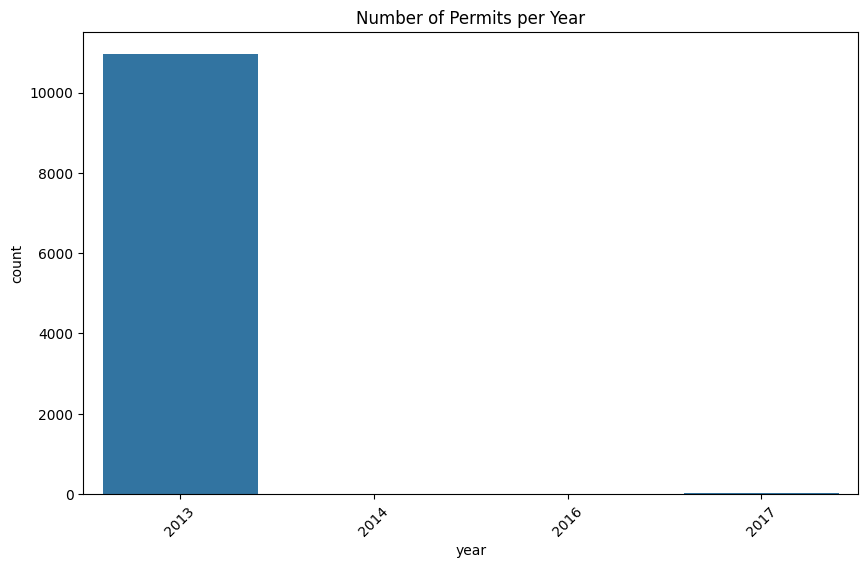

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='year', order=sorted(df['year'].unique()))
plt.xticks(rotation=45)
plt.title("Number of Permits per Year")
plt.show()

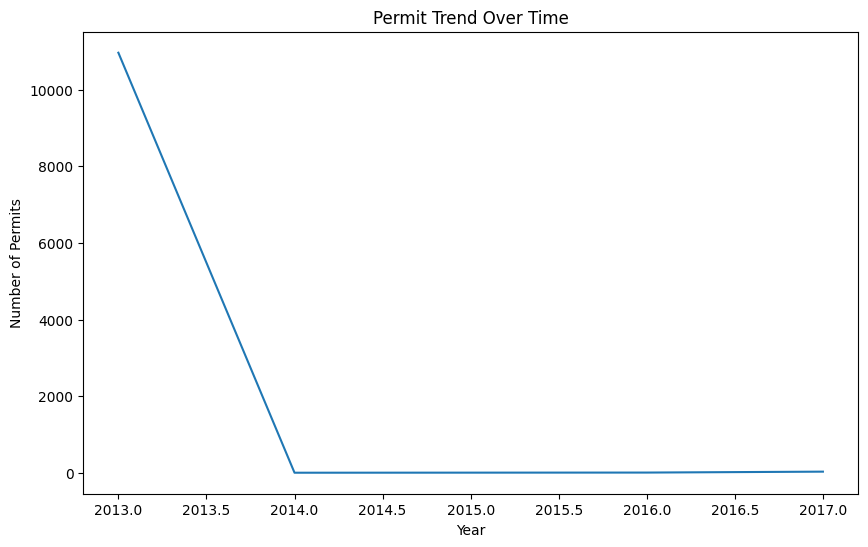

In [ ]:
year_counts = df.groupby('year').size()

plt.figure(figsize=(10,6))
plt.plot(year_counts.index, year_counts.values)
plt.title("Permit Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Permits")
plt.show()

In [ ]:
df['final_cost'] = df['Revised Cost']

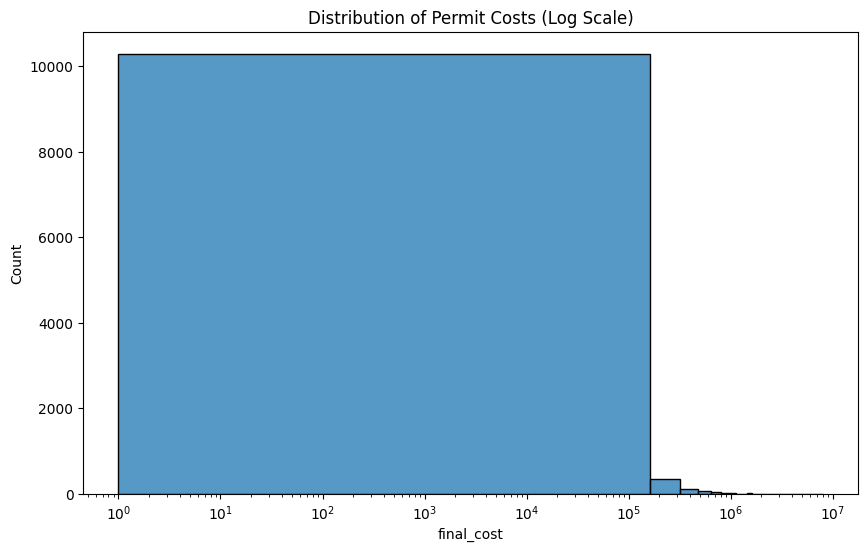

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['final_cost'], bins=50)
plt.xscale('log')
plt.title("Distribution of Permit Costs (Log Scale)")
plt.show()

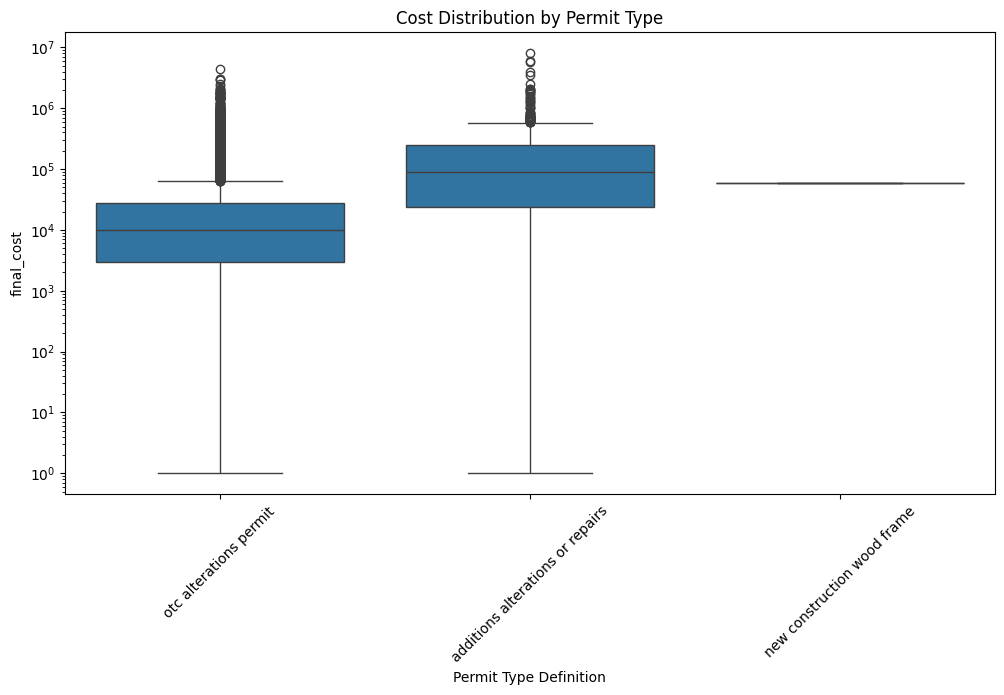

In [ ]:
top_types = df['Permit Type Definition'].value_counts().nlargest(10).index
df_top = df[df['Permit Type Definition'].isin(top_types)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='Permit Type Definition', y='final_cost')
plt.xticks(rotation=45)
plt.yscale('log')
plt.title("Cost Distribution by Permit Type")
plt.show()

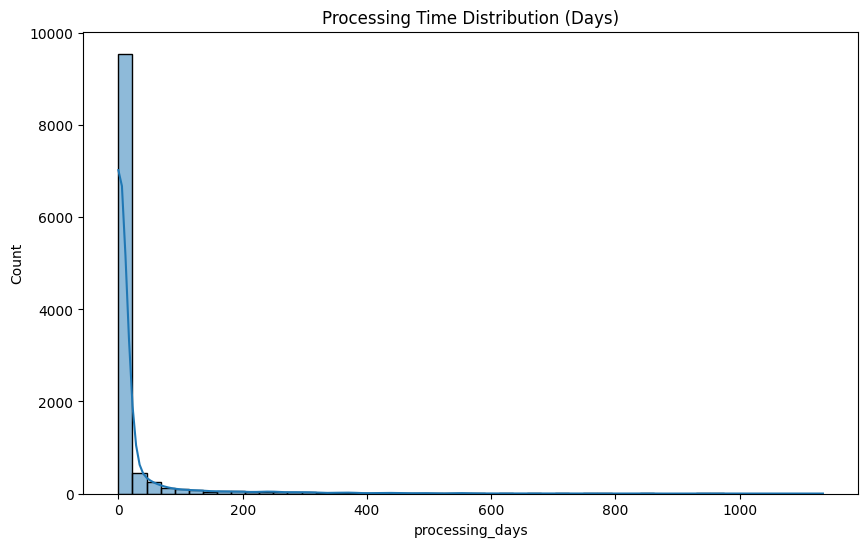

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['processing_days'], bins=50,kde=True)
plt.title("Processing Time Distribution (Days)")
plt.show()

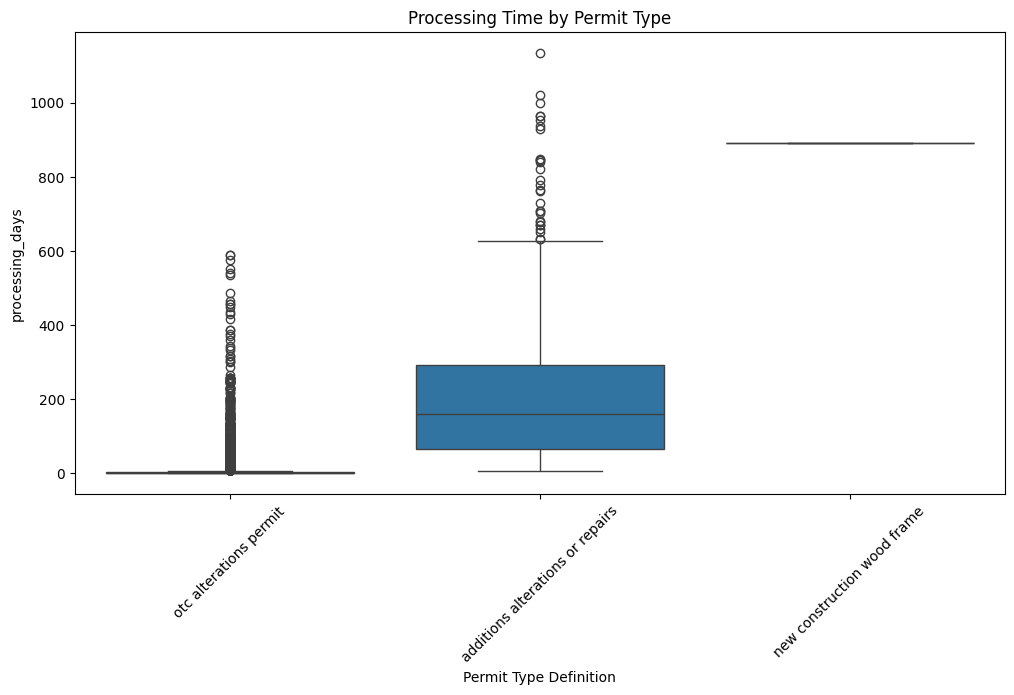

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='Permit Type Definition', y='processing_days')
plt.xticks(rotation=45)
plt.title("Processing Time by Permit Type")
plt.show()

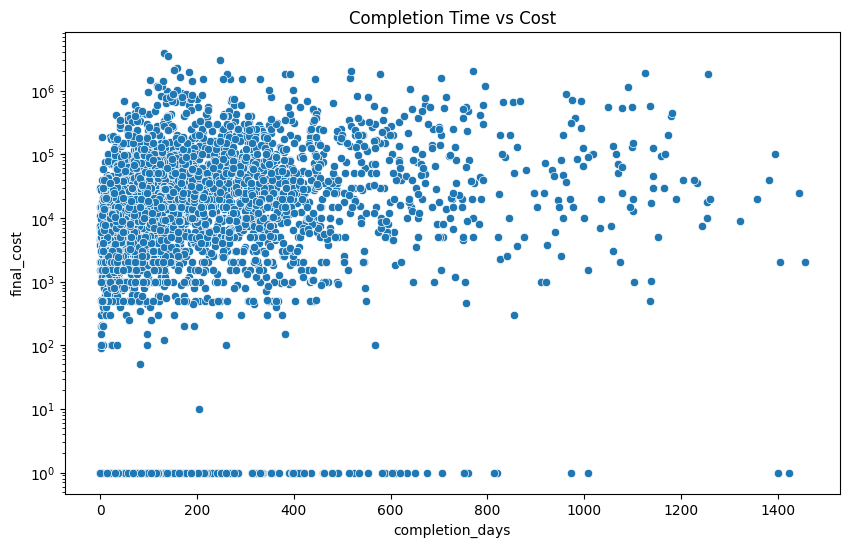

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(5000), x='completion_days', y='final_cost')
plt.yscale('log')
plt.title("Completion Time vs Cost")
plt.show()

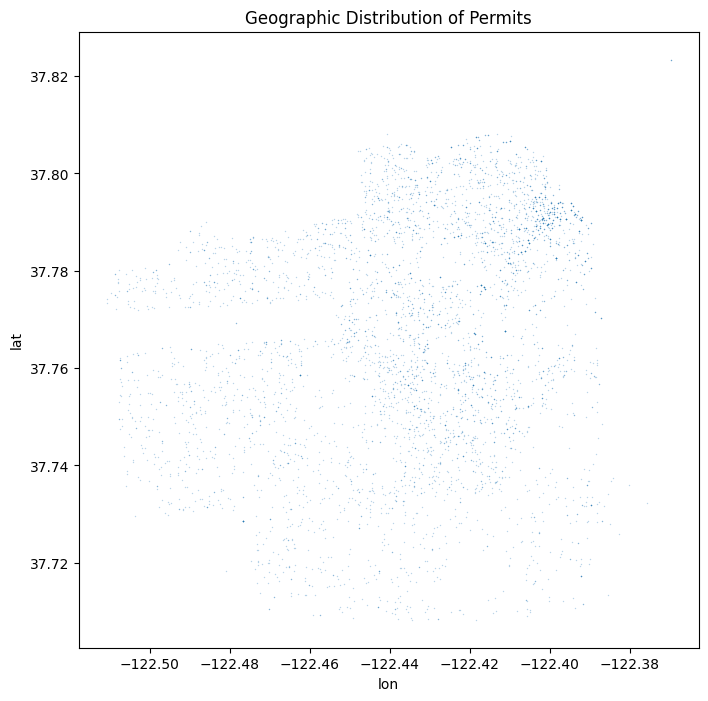

In [ ]:
# Extract latitude and longitude from the 'Location' column
df[['lat', 'lon']] = df['Location'].str.strip('()').str.split(', ', expand=True).astype(float)

plt.figure(figsize=(8,8))
sns.scatterplot(data=df.sample(5000), x='lon', y='lat', s=1, alpha=0.3)
plt.title("Geographic Distribution of Permits")
plt.show()

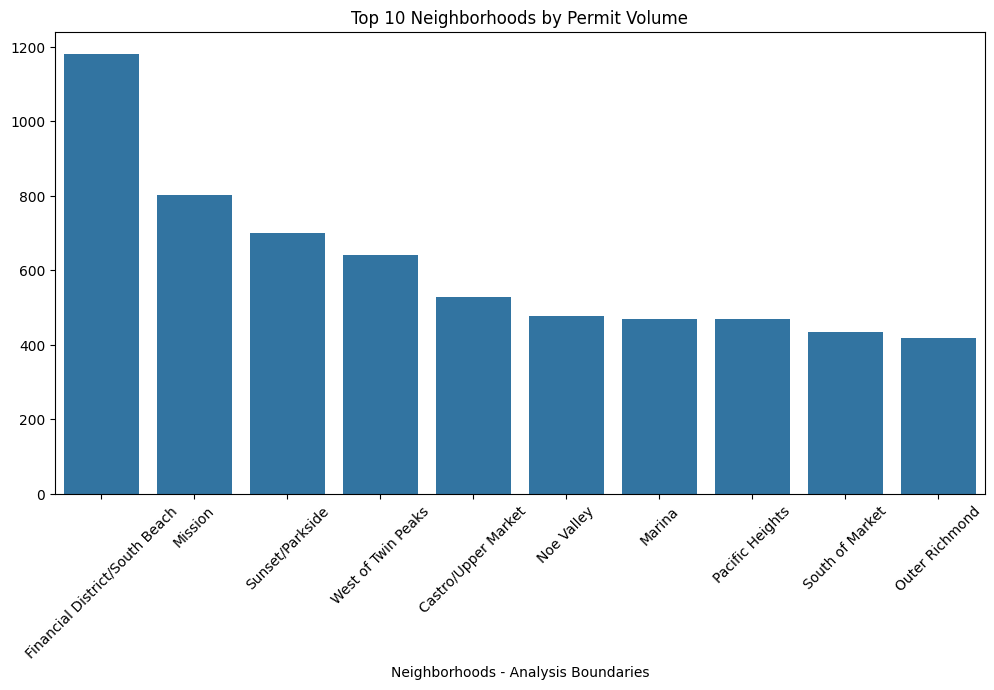

In [ ]:
top_neighborhoods = df['Neighborhoods - Analysis Boundaries'].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_neighborhoods.index, y=top_neighborhoods.values)
plt.xticks(rotation=45)
plt.title("Top 10 Neighborhoods by Permit Volume")
plt.show()

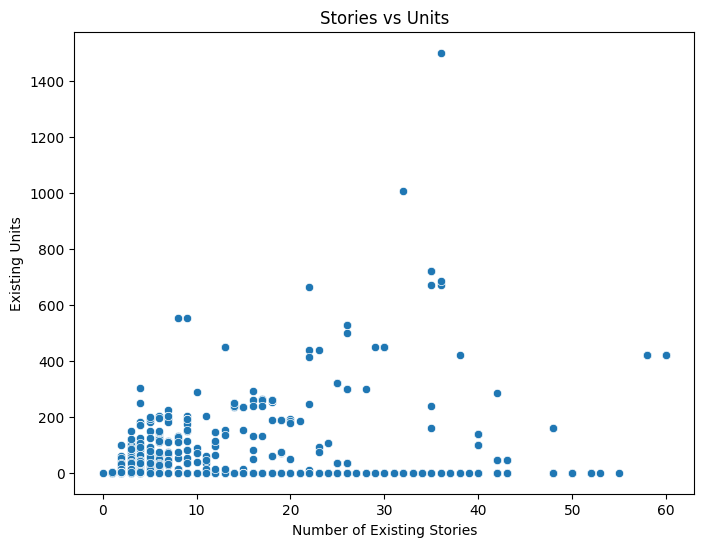

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df.sample(5000),
                x='Number of Existing Stories',
                y='Existing Units')
plt.title("Stories vs Units")
plt.show()

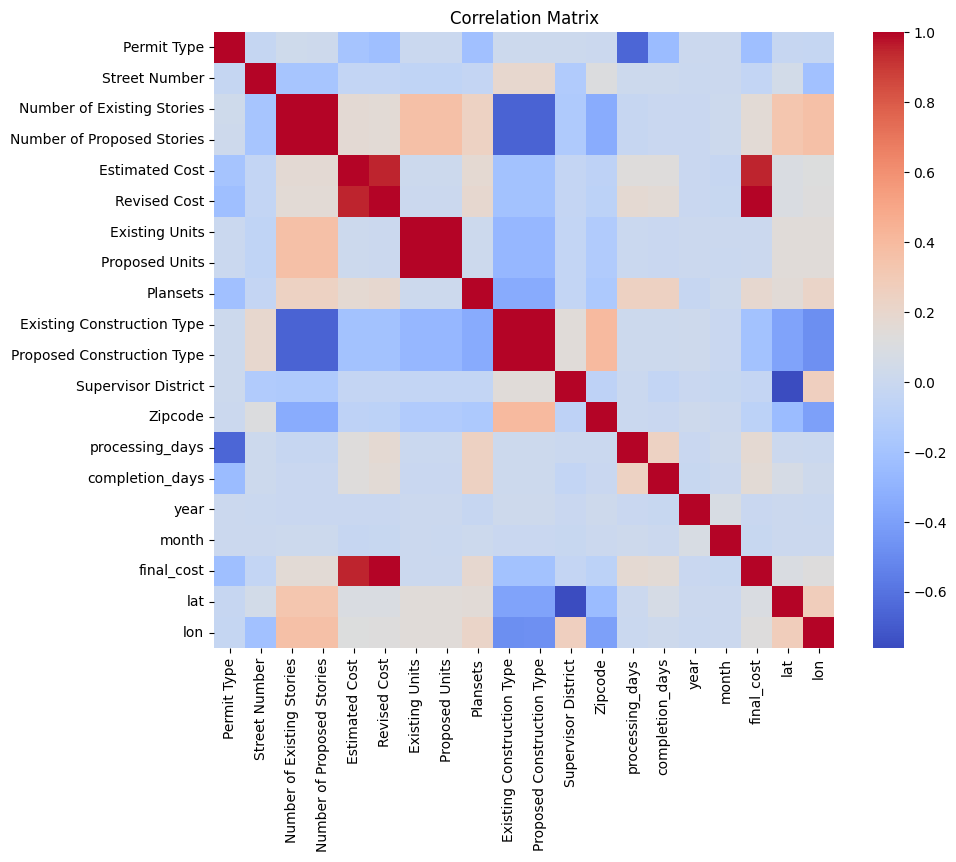

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

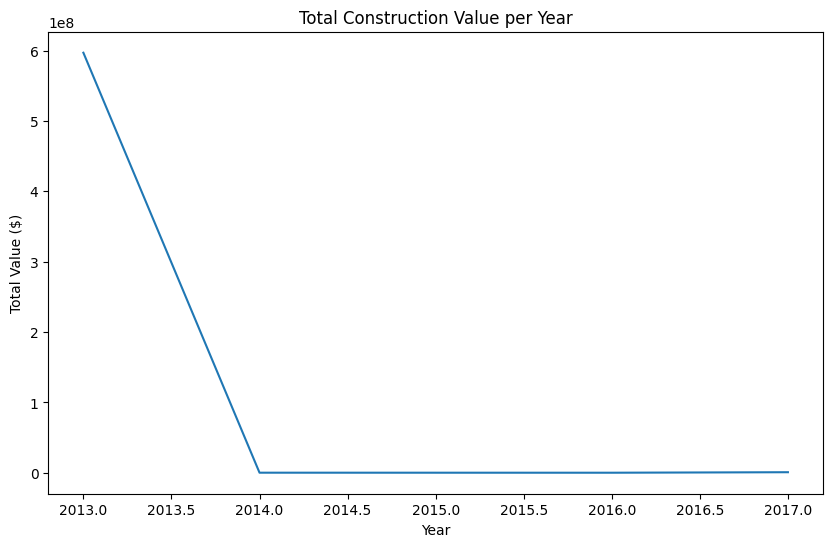

In [ ]:
year_value = df.groupby('year')['final_cost'].sum()

plt.figure(figsize=(10,6))
plt.plot(year_value.index, year_value.values)
plt.title("Total Construction Value per Year")
plt.xlabel("Year")
plt.ylabel("Total Value ($)")
plt.show()

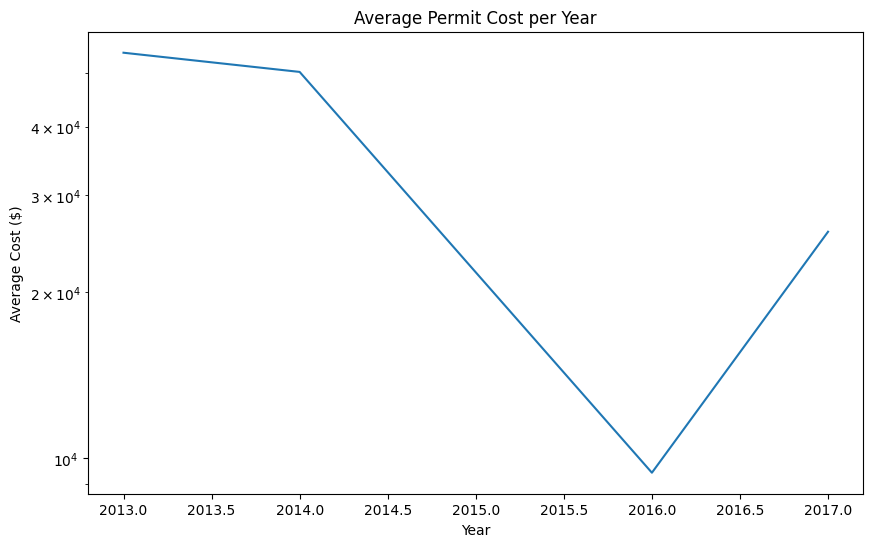

In [ ]:
avg_cost = df.groupby('year')['final_cost'].mean()

plt.figure(figsize=(10,6))
plt.plot(avg_cost.index, avg_cost.values)
plt.title("Average Permit Cost per Year")
plt.xlabel("Year")
plt.ylabel("Average Cost ($)")
plt.yscale('log')
plt.show()

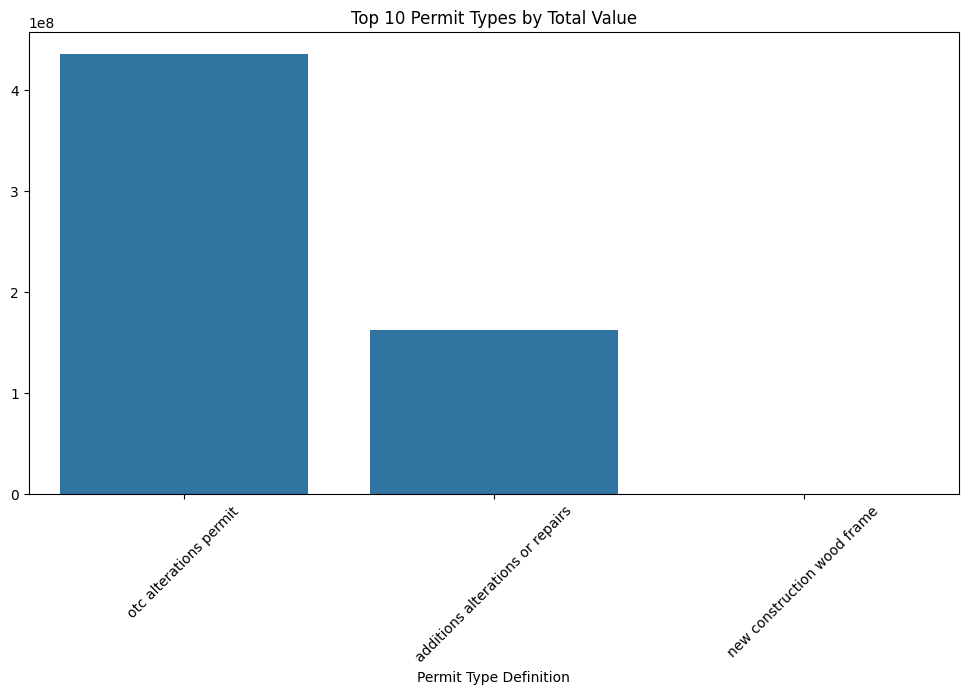

In [ ]:
top_value_types = (
    df.groupby('Permit Type Definition')['final_cost']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(x=top_value_types.index, y=top_value_types.values)
plt.xticks(rotation=45)
plt.title("Top 10 Permit Types by Total Value")
plt.show()

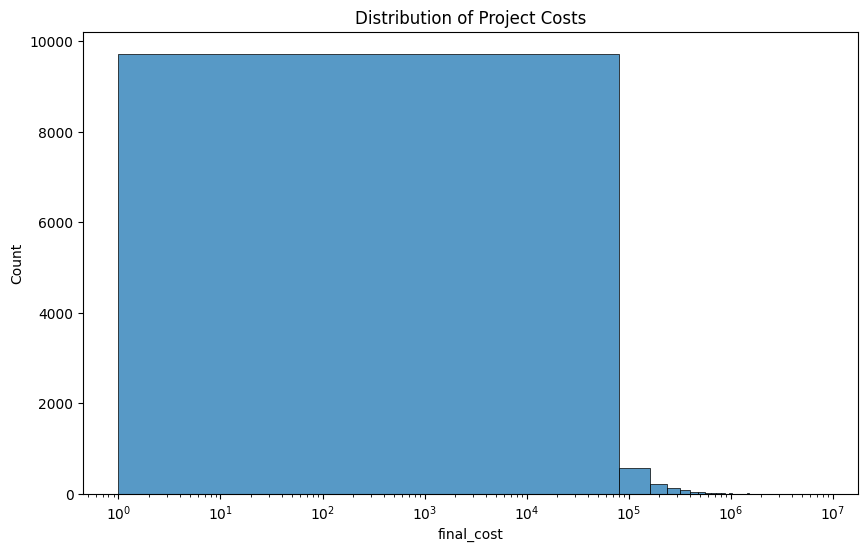

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['final_cost'], bins=100)
plt.xscale('log')
plt.title("Distribution of Project Costs")
plt.show()

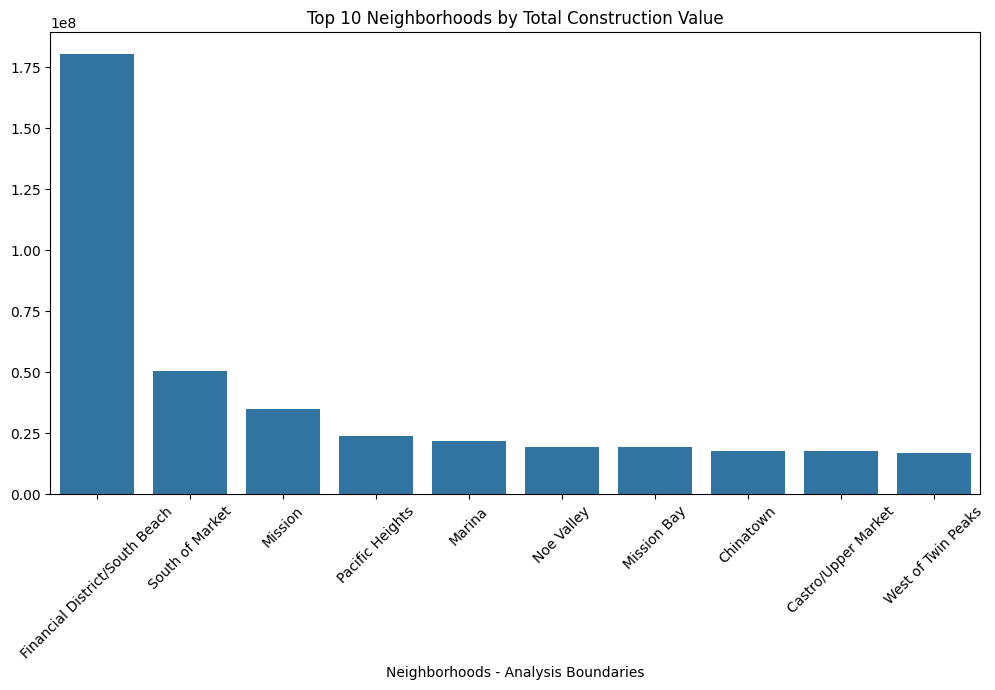

In [ ]:
neighborhood_value = (
    df.groupby('Neighborhoods - Analysis Boundaries')['final_cost']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(x=neighborhood_value.index,
            y=neighborhood_value.values)
plt.xticks(rotation=45)
plt.title("Top 10 Neighborhoods by Total Construction Value")
plt.show()

In [ ]:
mega = df[df['final_cost'] > df['final_cost'].quantile(0.95)]

In [ ]:
len(mega) / len(df)
mega['final_cost'].sum() / df['final_cost'].sum()

np.float64(0.5899186484478447)

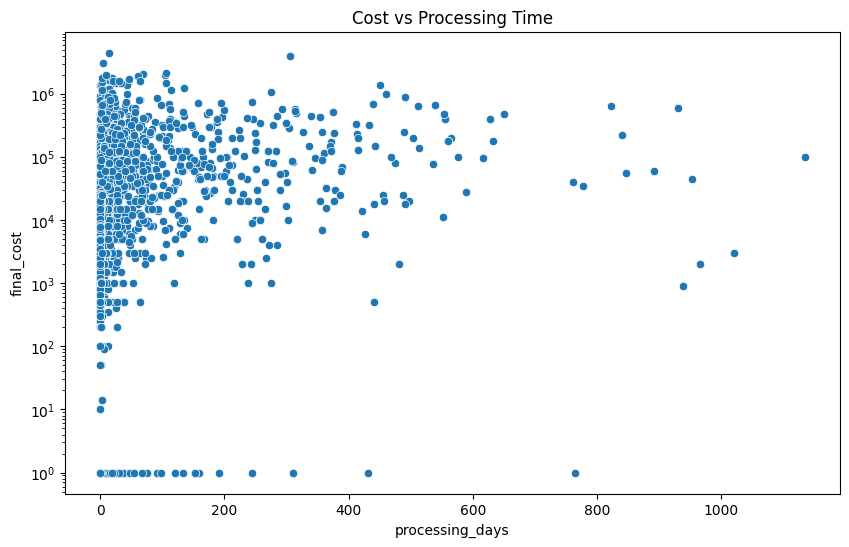

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),
    x='processing_days',
    y='final_cost'
)
plt.yscale('log')
plt.title("Cost vs Processing Time")
plt.show()